In [1]:
!pip install adjustText

In [2]:
import pandas as pd
import sys
import matplotlib.pyplot as plt
from adjustText import adjust_text
import re


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Change this to the desired folder location
IMAGE_FOLDER = './pattern_data/double_addi/'
from pathlib import Path
Path(IMAGE_FOLDER).mkdir(parents=True, exist_ok=True)

In [5]:
# Function to check if a pattern is covered
def is_covered(pattern):
    try:
        first, second = map(int, pattern.split('_'))  # Split pattern into two numbers
        return (0 <= first < 32) and (0 <= second < 1024)
    except ValueError:
        return False

In [13]:
file_paths_patterns = {
    0:'/content/drive/MyDrive/Py2C_ASIP_FPGA/pattern_data/profiling_data/double_addi_patterns.no_ext.mnistCNN.03-03-25.csv',
    1:'/content/drive/MyDrive/Py2C_ASIP_FPGA/pattern_data/profiling_data/double_addi_patterns.no_ext.mobileNet_v1.24-02-25.csv',
    2:'/content/drive/MyDrive/Py2C_ASIP_FPGA/pattern_data/profiling_data/double_addi_patterns.no_ext.ResNet50.03-03-25.csv',
    3:'/content/drive/MyDrive/Py2C_ASIP_FPGA/pattern_data/profiling_data/double_addi_patterns.no_ext.VGG16.24-02-25.csv',
    4:'/content/drive/MyDrive/Py2C_ASIP_FPGA/pattern_data/profiling_data/mobilenetv2_addi_pattern.csv',
    5:'/content/drive/MyDrive/Py2C_ASIP_FPGA/pattern_data/profiling_data/densenet121_addi_pattern.csv'
}

instruction_count_filenames = {
    2:"/content/drive/MyDrive/Py2C_ASIP_FPGA/pattern_data/profiling_data/inst_count.no_ext.ResNet50.05-03-25.csv",    # ResNet50
    0:"/content/drive/MyDrive/Py2C_ASIP_FPGA/pattern_data/profiling_data/inst_count.no_ext.mnistCNN.28-11-24.csv",    # mnistCNN
    1:"/content/drive/MyDrive/Py2C_ASIP_FPGA/pattern_data/profiling_data/inst_count.no_ext.mobileNet_v1.04-01-25.csv", # MobileNet
    3:"/content/drive/MyDrive/Py2C_ASIP_FPGA/pattern_data/profiling_data/inst_count.no_ext.VGG16.10-01-25.csv",        # VGG16
    4:"/content/drive/MyDrive/Py2C_ASIP_FPGA/pattern_data/profiling_data/inst_count.no_ext.mobileNet_v2.08-07-25.csv",
    5:"/content/drive/MyDrive/Py2C_ASIP_FPGA/pattern_data/profiling_data/inst_count.no_ext.densenet121.08-07-25.csv"
}

table = pd.DataFrame()
model_names_list = ['LeNet-5*', 'MobileNet', 'ResNet50', 'VGG16', 'MobileNetV2', 'DenseNet121']
addi_count_list = []
tot_pattern_count_list = []

for model, file_path in file_paths_patterns.items():
    # get the total count of addi + addi patterns
    df = pd.read_csv(file_path)
    df.sort_values('cycle_count', inplace=True, ascending=False)
    tot_pattern_count_list.append(df['cycle_count'].sum())
    # get add count
    pattern = r"""
        addi,(\d+),\d+
    """
    with open(instruction_count_filenames[model], 'r', encoding='utf-8') as file:
            content = file.read()
    match = re.search(pattern, content, re.VERBOSE | re.MULTILINE)
    addi_count_list.append(match.group(1))

table['model_name'] = model_names_list
table['addi_count'] = addi_count_list
table['addi_addi_count'] = tot_pattern_count_list

display(table)


,model_name,addi_count,addi_addi_count
0,LeNet-5*,683213,288536
1,MobileNet,25449176,8151239
2,ResNet50,1805151250,530995267
3,VGG16,6900499100,2288928117
4,MobileNetV2,4546125,53519109
5,DenseNet121,7191345,479631159


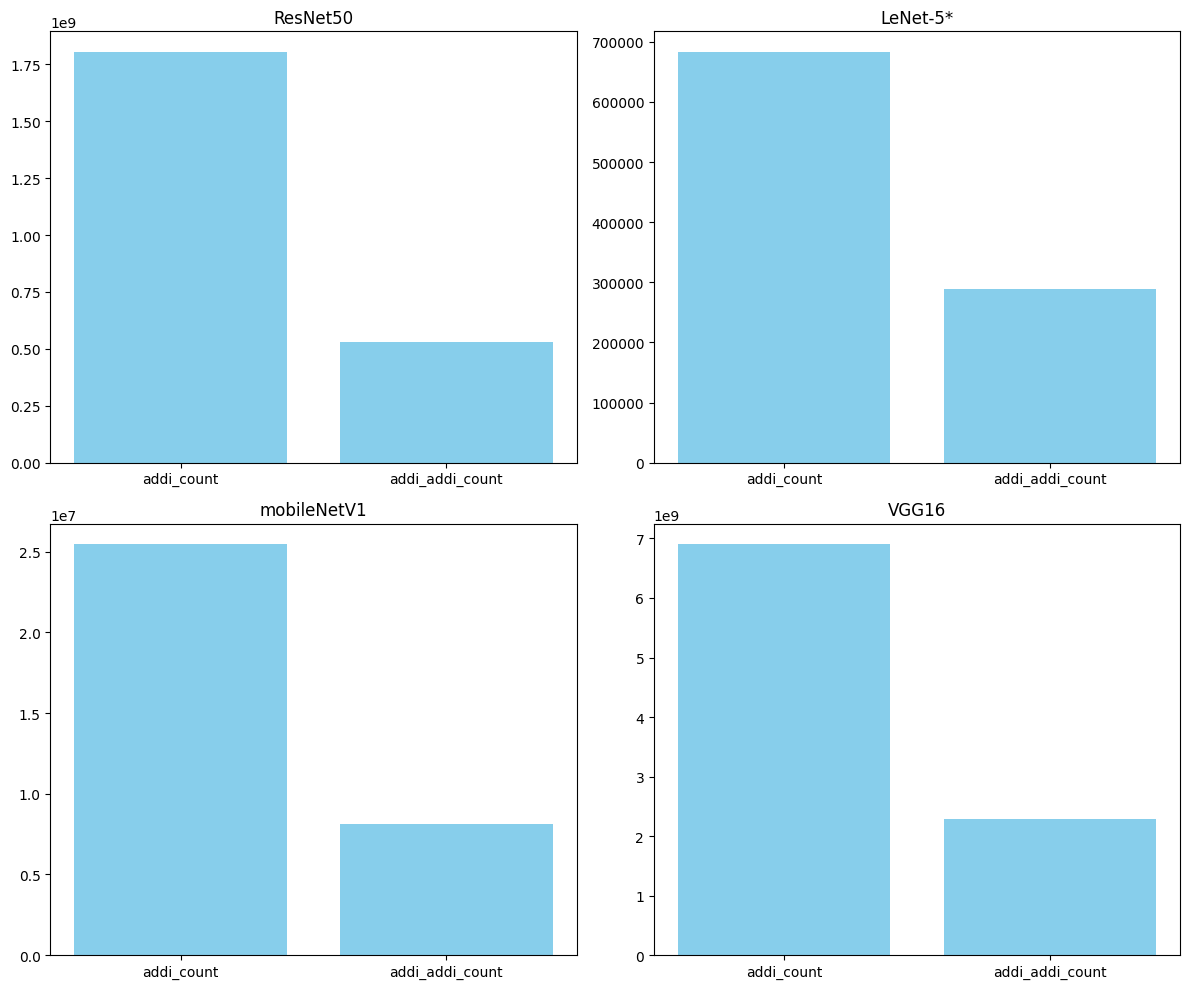

In [14]:
df = table

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot for ResNet50
axes[0, 0].bar(['addi_count','addi_addi_count'],
        [int(df.loc[df['model_name'] == 'ResNet50', 'addi_count'].iloc[0]),
         int(df.loc[df['model_name'] == 'ResNet50', 'addi_addi_count'].iloc[0])], color='skyblue')
axes[0, 0].set_title('ResNet50')

# Plot for LeNet-5
axes[0, 1].bar(['addi_count','addi_addi_count'],
        [int(df.loc[df['model_name'] == 'LeNet-5*', 'addi_count'].iloc[0]),
         int(df.loc[df['model_name'] == 'LeNet-5*', 'addi_addi_count'].iloc[0])], color='skyblue')
axes[0, 1].set_title('LeNet-5*')

# Plot for MobileNet
axes[1, 0].bar(['addi_count','addi_addi_count'],
        [int(df.loc[df['model_name'] == 'MobileNet', 'addi_count'].iloc[0]),
         int(df.loc[df['model_name'] == 'MobileNet', 'addi_addi_count'].iloc[0])], color='skyblue')
axes[1, 0].set_title('mobileNetV1')

# Plot for VGG16
axes[1, 1].bar(['addi_count','addi_addi_count'],
        [int(df.loc[df['model_name'] == 'VGG16', 'addi_count'].iloc[0]),
         int(df.loc[df['model_name'] == 'VGG16', 'addi_addi_count'].iloc[0])], color='skyblue')
axes[1, 1].set_title('VGG16')

# Adjust layout
plt.tight_layout()

# Show the plot
plt.savefig('./pattern_data/addi_addi_pattern_comparison.eps')
plt.show()

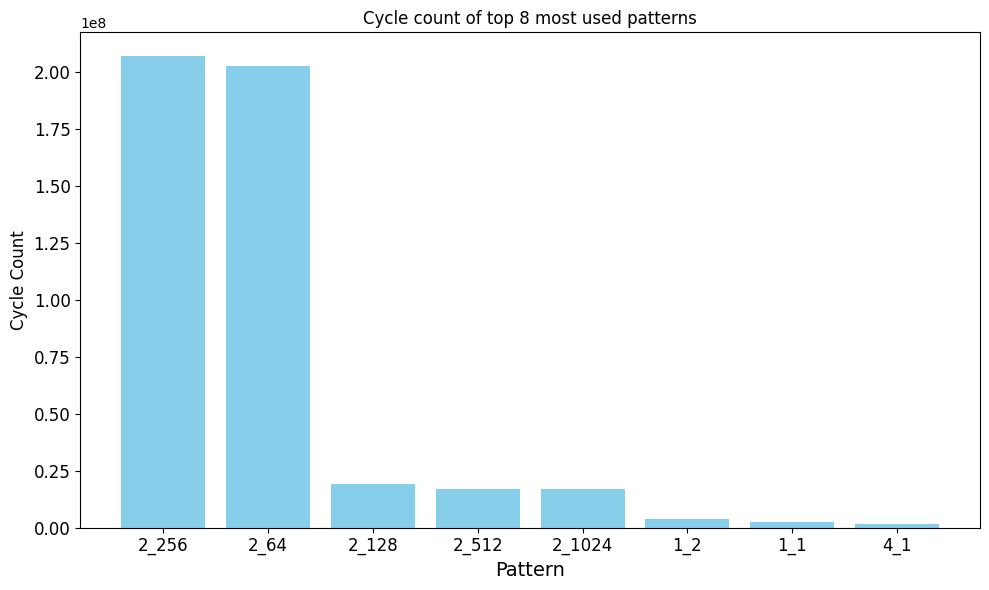

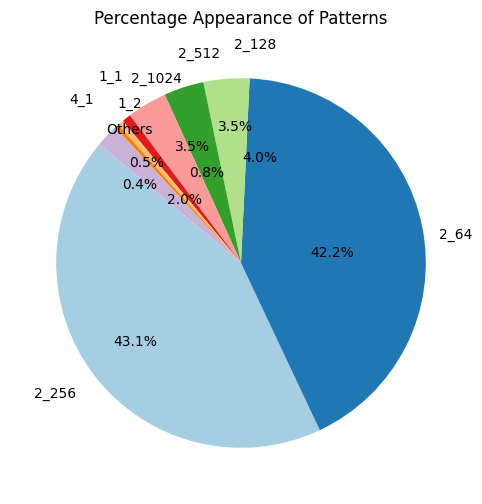

covered
False     23323884
True     456307275
Name: cycle_count, dtype: int64
479631159
covered
False     4.862879
True     95.137121
Name: cycle_count, dtype: float64


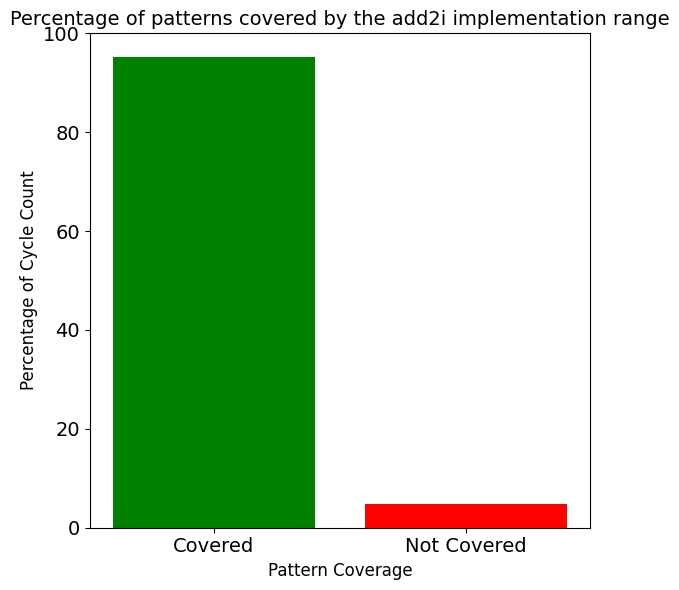

,pattern,cycle_count,covered
227,2_256,206831620,True
242,2_64,202604544,True
260,2_128,19267588,True
230,2_512,16777218,True
234,2_1024,16777216,False
...,...,...,...
3,-2048_-2013,1,False
4,28_20,1,True
555,384_437,0,False
558,24_100,0,True


479631159


In [16]:
# Change this to the file with the pattern counts desired
#file_path = "/content/drive/MyDrive/Py2C_ASIP_FPGA/pattern_data/profiling_data/double_addi_patterns.no_ext.ResNet50.03-03-25.csv"
file_path = "/content/drive/MyDrive/Py2C_ASIP_FPGA/pattern_data/profiling_data/densenet121_addi_pattern.csv"
df = pd.read_csv(file_path)
df.sort_values('cycle_count', inplace=True, ascending=False)
# Plot a bar chart
plt.figure(figsize=(10, 6))
top_N = 8
plt.bar(df.head(top_N)['pattern'], df.head(top_N)['cycle_count'], color='skyblue')

plt.xlabel('Pattern', fontsize=14)
plt.ylabel('Cycle Count', fontsize=12)

plt.xticks(rotation=0, fontsize=12)
plt.yticks(fontsize=12)
title = str('Cycle count of top ' + str(top_N) + ' most used patterns')
plt.title(title)
plt.tight_layout()
plt.savefig(str(IMAGE_FOLDER + 'cycle_count_bar.png'))
plt.show()
#====================================================
top_N = 8

# Get the top 10 patterns
top_10 = df.head(top_N)

others_count = df['cycle_count'].sum() - top_10['cycle_count'].sum()

# Create a new dataframe for the pie chart, including the "Others" category
pie_data = top_10[['pattern', 'cycle_count']].copy()
if others_count > 0:
    pie_data.loc[len(pie_data.index)] = ['Others', others_count]

from adjustText import adjust_text

plt.figure(figsize=(10, 6))
wedges, texts, autotexts = plt.pie(
    pie_data['cycle_count'],
    labels=pie_data['pattern'],
    autopct='%1.1f%%',
    colors=plt.cm.Paired.colors,
    startangle=140
)

# Adjust text positions
adjust_text(texts + autotexts, expand=(1.2, 1.5))

plt.title('Percentage Appearance of Patterns')
plt.savefig(str(IMAGE_FOLDER + 'percentage_pie.png'))
plt.show()


#====================================================
# Apply the function to categorize each pattern
df['covered'] = df['pattern'].apply(is_covered)

# Aggregate the cycle counts for covered and not covered patterns
coverage_counts = df.groupby('covered')['cycle_count'].sum()
print(coverage_counts)

# Calculate total cycle count
total_cycle_count = coverage_counts.sum()
print(total_cycle_count)

# Compute percentages
percentages = (coverage_counts / total_cycle_count) * 100
print(percentages)

labels = ['Covered', 'Not Covered']
values = [percentages.get(True, 0), percentages.get(False, 0)]

# Create the bar chart with percentages
plt.figure(figsize=(6, 6))
bars = plt.bar(labels, values, color=['green', 'red'])

# Add percentage labels on top of bars
# for bar, percent in zip(bars, values):
#     plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() -4, f'{percent:.1f}%', ha='center', fontsize=12)

plt.xlabel('Pattern Coverage', fontsize=12)
plt.ylabel('Percentage of Cycle Count', fontsize=12)
plt.title('Percentage of patterns covered by the add2i implementation range', fontsize=14)

plt.ylim(0, 100)
# Adjust fontsize
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.tight_layout()
plt.savefig(str(IMAGE_FOLDER + 'coverage_bar.png'))
plt.show()

display(df)
print(df['cycle_count'].sum())